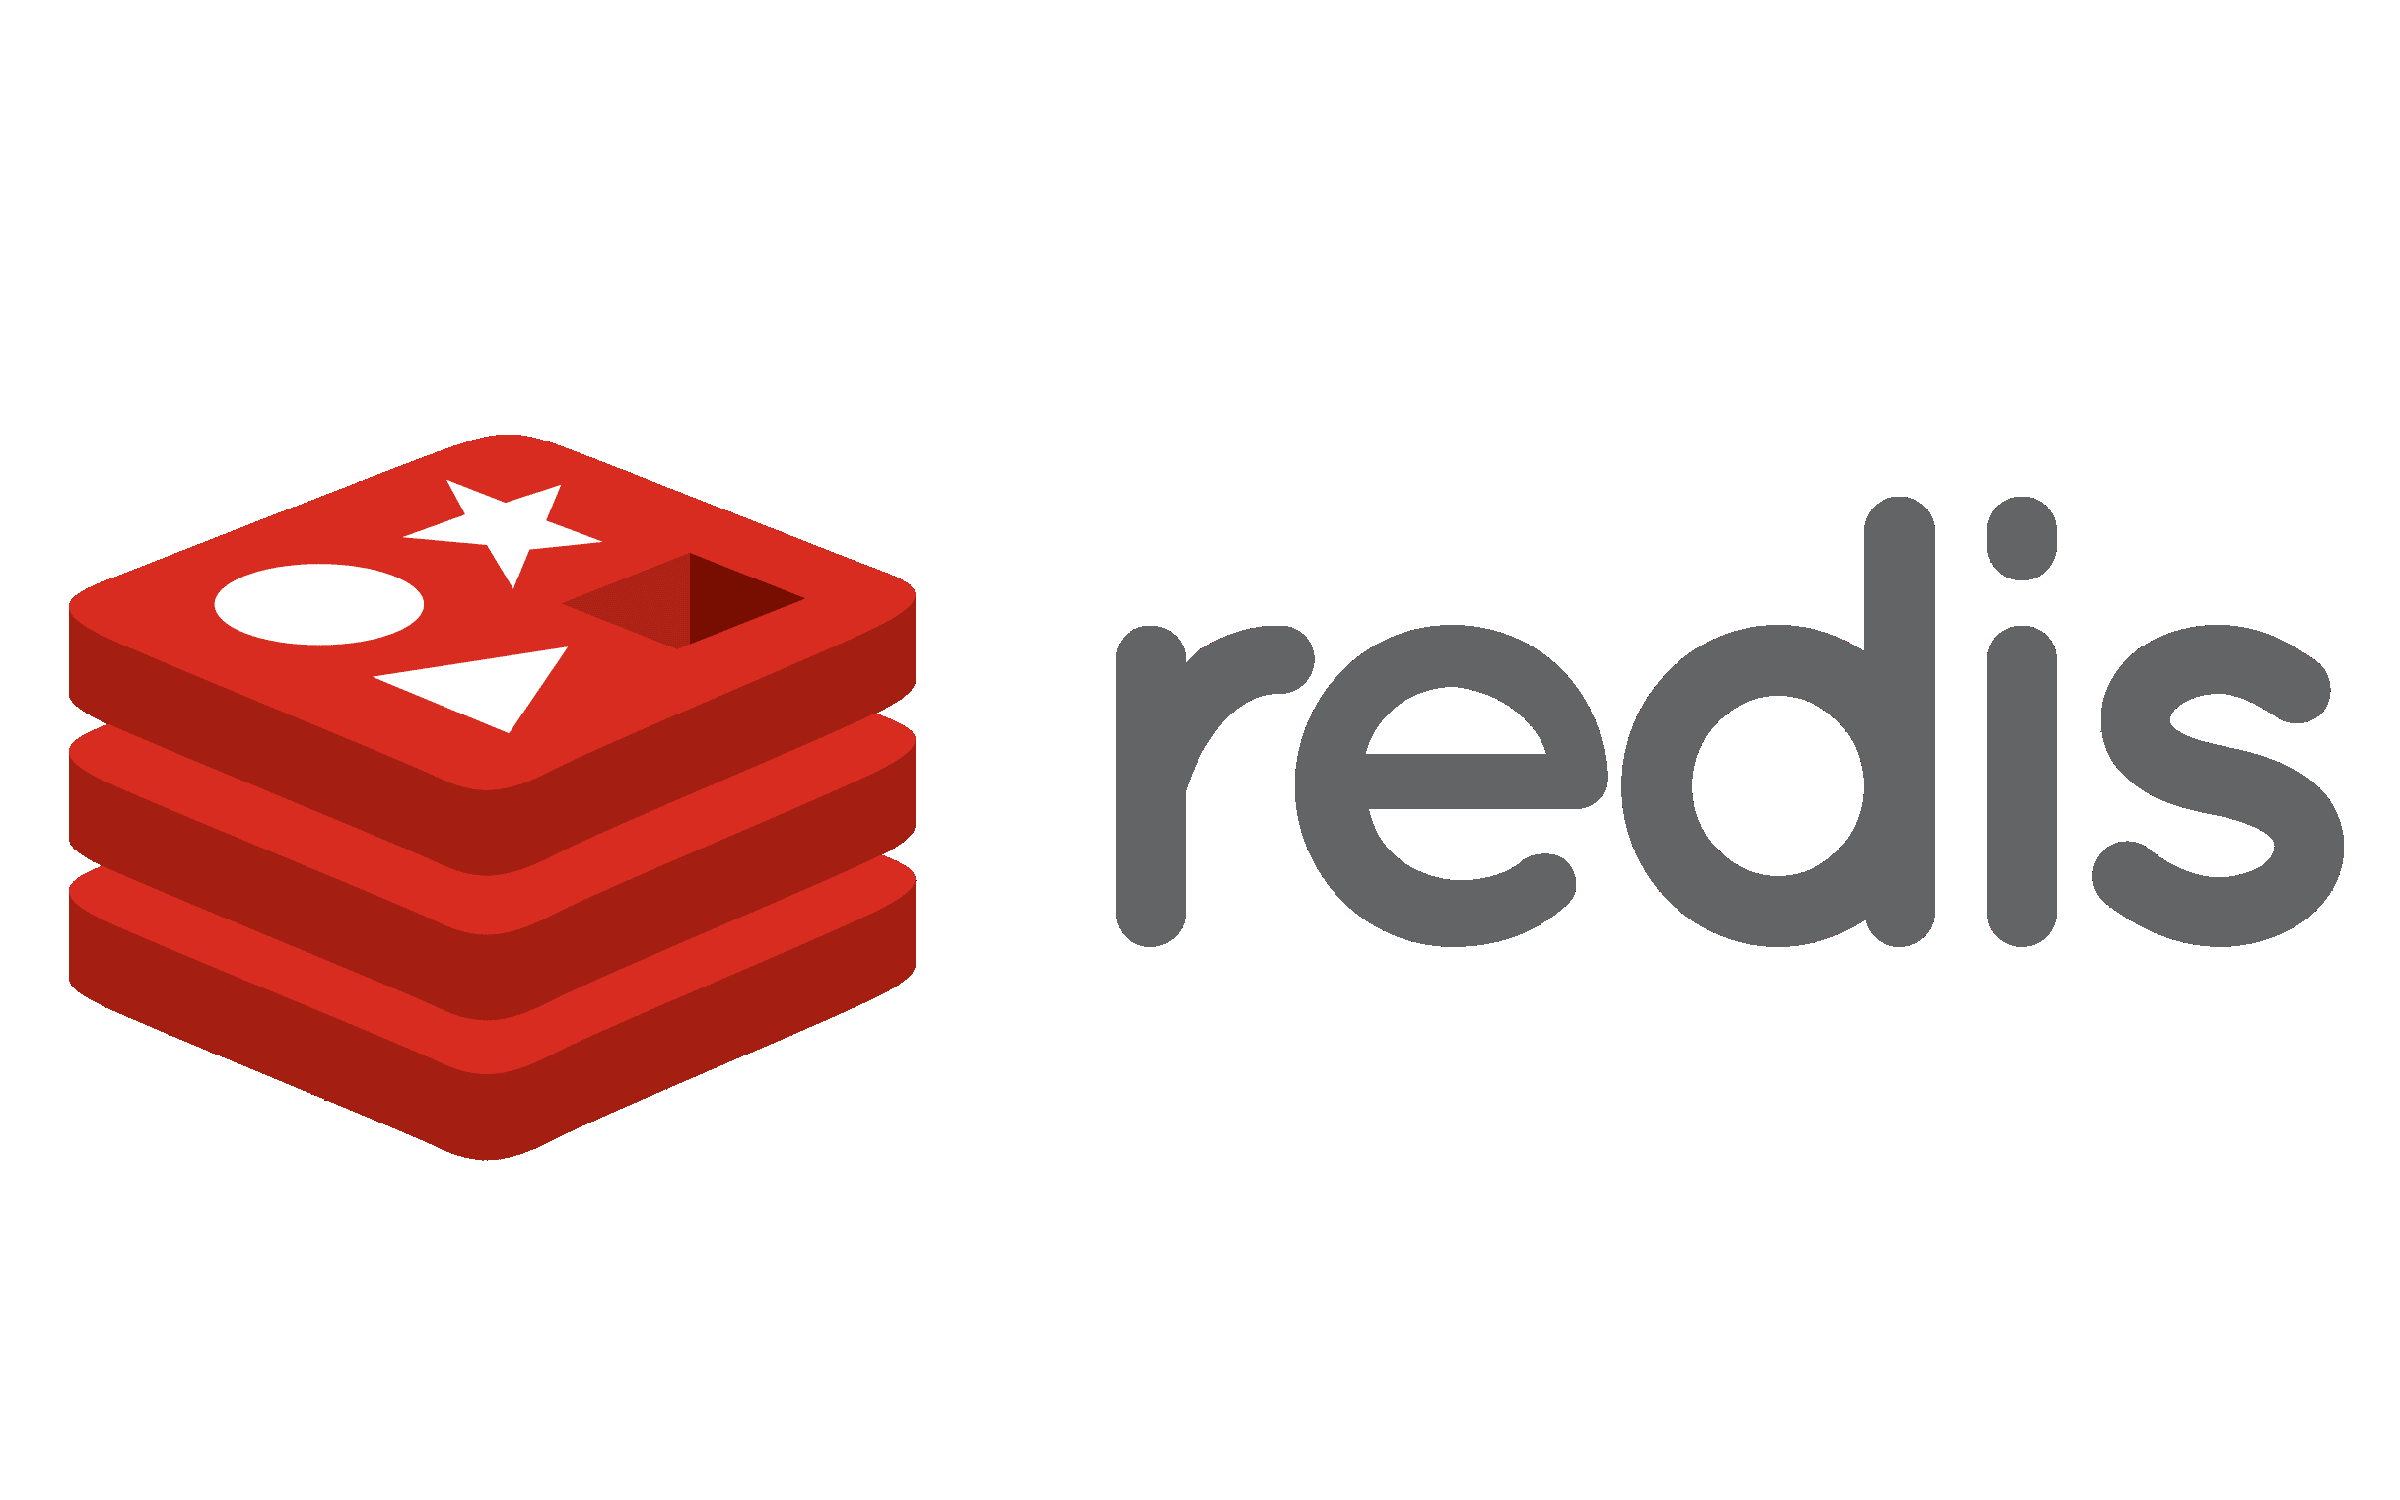

# TP REDIS Clustering



:::{important} Objectif

Ce travail pratique a pour but de vous initier à la solution de clustering proposée par Redis et de vous aider à comprendre son fonctionnement.

Voici les objectifs détaillés de ce TP :

- **Découverte du clustering Redis** : Vous explorerez les principes et les mécanismes sous-jacents du clustering avec Redis, y compris la répartition des données, la tolérance aux pannes et la haute disponibilité.

- **Mise en place d'un cluster Redis** : Vous serez guidé dans la configuration d'un cluster Redis selon une architecture précisée dans le TP. Cette étape comprendra la configuration des instances Redis, leur interconnexion, et l'assurance que le cluster est opérationnel et optimisé pour la performance et la résilience.

Ce TP vous permettra de maîtriser les concepts et les pratiques essentiels pour déployer et gérer un cluster Redis efficace, améliorant ainsi la scalabilité et la robustesse de vos applications.

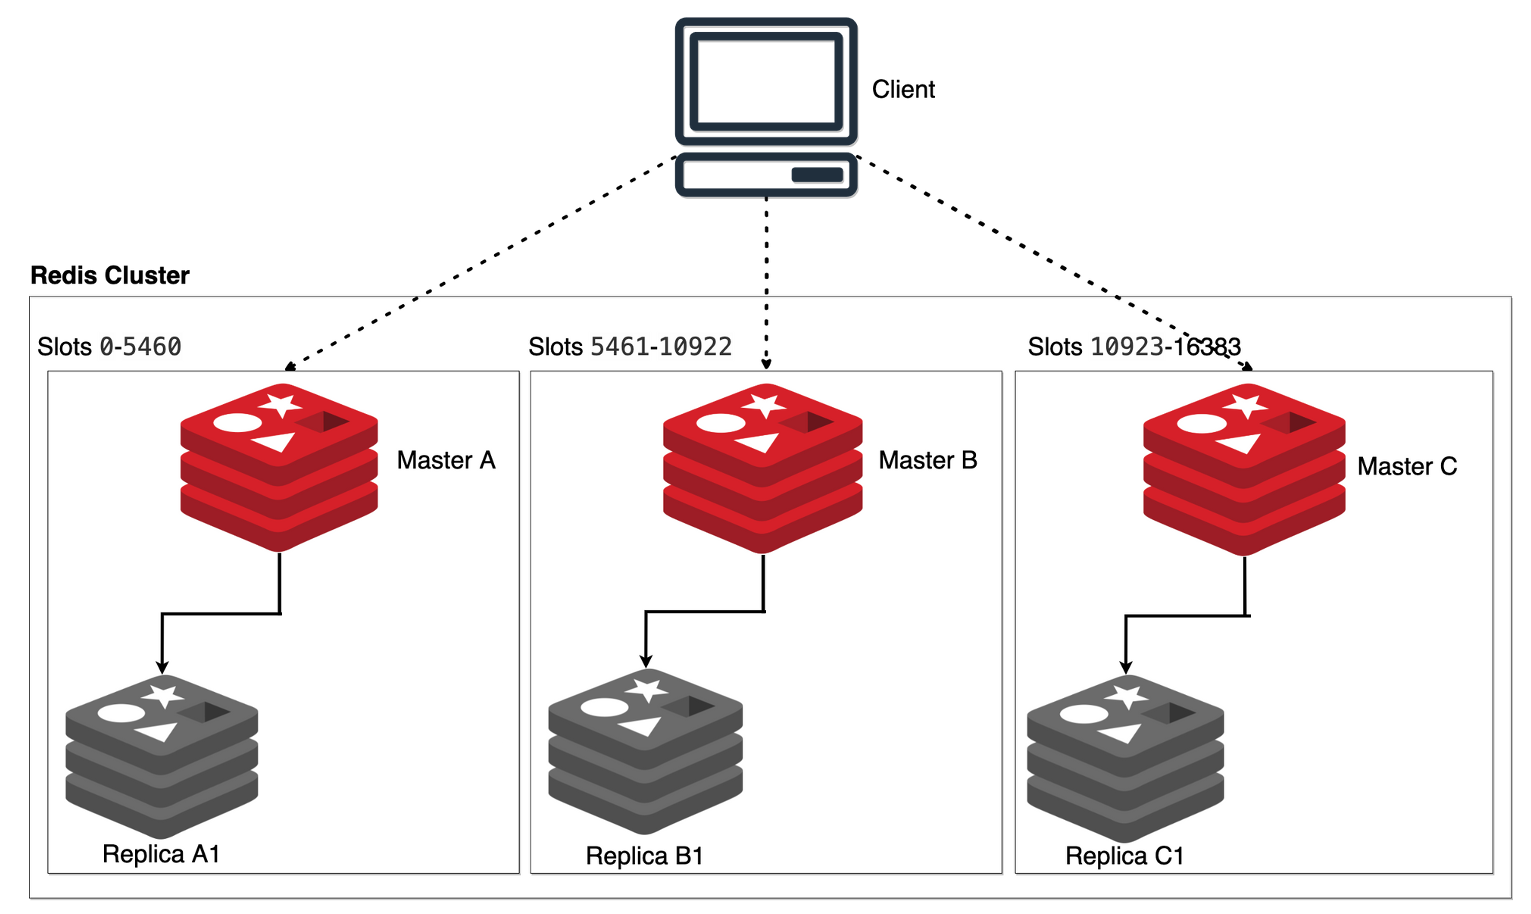


L'aspect sécurité ne sera pas abordé dans ce TP.

## Prérequis

* Vérifier que Docker desktop est bien démarré
* Ouvrer un terminal ssh
* A partir du terminal, positionnez vous dans le répertoire  $monrepertoire/docker.
  



## Déploiement de votre cluster Redis 

La solution de clustering avec Redis n'est possible qu'avec un minimum de 6 instances redis, c'est pourquoi le fichier docker-compose.yml définit 6 containers redis-node-1 rà redis-node-6.
Bien entendu chaque instance redis disposera de son propre volume.

Pour instancier votre cluster redus, exécuter la commande suivante :

Une phase d'initialisation sera nécessaire pour indiquer aux différentes instances quelles font parties d'un cluster.

Cette phase d'initialisation est réalisée par le service redis-cluster-creator

#### <font color='red'>A partir de la sortie de redis-cluster-creator, identifier les Masters et les Slaves de votre cluster : </font>

On utilisera le container redis pour se connecter à notre cluster redis.
Pour cela démarrer le container redis


Puis accéder en interactif sur le container redis :

Utiliser le client redis-cli pour vous connecter au cluster redis

<font color='red'>Identifier les masters, les réplicas et les slots de votre cluster ?

**Note** La commande `cluster nodes` peut être votre ami  
</font>

Jouons à présent avec notre cluster !
Créer la clé suivante 

#### <font color='red'>Que constatez vous ?</red>

Creer les clé suivantes :


La commande `CLUSTER KEYSLOT "le nom de ma clé"` permet d'obtenir la valeur du hash utiliser pour définir le slot et donc le noeud sur lequel la clé sera stockée.

#### <font color='red'>A partir de cette commande identifier le shard sur lequel est stocké chacune de vos clés créée précédemment ?

On pourra vérifier avec la commande GET, l'attribution du noeud.</font>

Lister l'ensemble des clés :

#### <font color='red'>Que constatez vous ?</font>

Consulter la liste des noeuds avec la commande `CLUSTER NODES`

Arrêter un des noeuds master :

Verifier l'état du cluster 

#### <font color='red'>Que constatez vous ?</font>

#### <font color='red'>Essayer d'accéder à une des clés stocké sur le noeud master en panne:</font>

#### <font color='red'>Que constatez vous si vous refaites un `CLUSTER NODES`?</font>

Redis permet de créer des affinités entres les clés afin qu'un ensemble de clés concernant par exemple un même utilisateur soit conservé sur une même instance Redis. 

Prenons l'exemple suivant :

La valeur de KEYSLOT de maclé `user1.prenom` est 12200.

Si on veut créer une seconde clé `user1.age` qui concerne le user1 sa valeur de KEYSLOT 4417 fera que cette clé sera stockée sur un noeud différent de la clé `user1.prenom`.
Pour remdéier à cette problématique, on peut influencer la valeur de KEYSLOT en demandant à ce que la valeur de KEYSLOT soit calculée sur une autre expression que le nom de la clé.

Pour cela il vous suffit tout simplement d'indiquer entre {} la chaine pour le calcul du KEYSLOT.

cluster KEYSLOT user1.age{user1.prenom}  --> 12200 




<font color='red'>Essayez à présent d'insérer une nouvelle clé `macleXY` avec une valeur quelconque mais celle-ci devra être gérée sur la même instance que la clé `macle3`


set macleXY{macle3} "test"

#### <font color='red'>Retourner la valeur de votre nouvelle clé macleXY ?</font>

Le master en pannne a été finalement réparé.
Vous pouvez réintégrer le container redis-node-3 dans le clsuter. 

#### <font color='red'>Que constatez vous ?</font>

## Nettoyage

Une fois que vous avez terminé avec Redis, vous pouvez supprimer les containers redis :